# <center> **FINA 6339: Quantitative Portfolio Management** </center>

## **RESEARCH PROJECT**

### Miles Choquette choquette.m@northeastern.edu
### Luan Ferreira de Souza ferreiradesouza.l@northeastern.edu
### Luka Gabadadze gabadadze.l@northeastern.edu
### Jingying Gao gao.jingyi@northeastern.edu
### Zhe Chen chen.zh@northeastern.edu

---

# Nelson-Siegel / Diebold-Li VAR Bond ETF Strategy

## Abstract

This paper develops a systematic fixed income allocation strategy across U.S. Treasury ETFs by combining
the Nelson-Siegel yield curve model with the Diebold-Li dynamic factor extension. Each month, Nelson-
Siegel is fit to the Treasury par yield curve, extracting three factors—level (β0), slope (β1), and curvature
(β2)—along with cross-sectional mispricing residuals at each ETF’s effective maturity. Following Diebold
and Li (2006), the factors are modeled jointly as a VAR(1) system to generate one-month-ahead yield curve
forecasts on an expanding window. Portfolio construction is driven by two signals: a mispricing signal
derived from Nelson-Siegel residuals and a directional signal from the VAR(1) factor forecasts, with factor
loadings tilted 60/20/20 toward slope based on individual factor attribution. Signal-proportional and top-N
concentration weighting schemes are backtested against an equal-weight benchmark across seven Treasury
ETFs from 2008 to 2024, with Sharpe ratio significance assessed via the Jobson-Korkie (1981) test. A sub-
period analysis over 2018–2021 stress-tests the model through the 2019 Federal Reserve rate-cut cycle and
the 2020 COVID-19 shock. Results indicate that the slope factor β1 carries the dominant predictive power,
and that layering curve mispricing onto directional forecasts produces consistent risk-adjusted outperfor-
mance relative to passive equal-weighting.

---

## Code

Fits the three-factor Nelson-Siegel curve each month, then runs an expanding-window VAR(1) on the factors to forecast the yield curve one month ahead. From there, two signals drive the allocation: (1) how much each ETF's implied yield deviates from the fitted curve (mispricing), and (2) whether rates at that maturity are forecast to fall (directional). Three weighting schemes — top-3, signal-proportional, rank — are backtested against an equal-weight benchmark across 7 Treasury ETFs from 2008–2024.

---

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.vector_ar.var_model import VAR
import warnings
import os
warnings.filterwarnings('ignore')

In [2]:
# Date range
START  = '2008-01-01'
END    = '2024-12-31'

# Nelson-Siegel
LAMBDA = 0.0609          # Fixed decay; matches ~30-month hump in NS curve

# Treasury yield maturities from FRED (years)
MATURITIES = [2, 3, 5, 7, 10, 20, 30]

# ETF universe & approximate effective durations (years)
ETFS = ['SHV', 'SHY', 'IEI', 'IEF', 'TLH', 'TLT', 'EDV']
ETF_MATS = {
    'SHV': 0.5,   # <1Y
    'SHY': 2.0,
    'IEI': 4.5,
    'IEF': 8.5,
    'TLH': 15.0,
    'TLT': 20.0,
    'EDV': 25.0,
}

# Backtest & weighting
TOP_N          = 3       # ETFs to hold in top-N strategy
VAR_INIT_MONTHS = 36    # Expanding-window burn-in for VAR(1)
FACTOR_WEIGHTS = {'b0': 0.20, 'b1': 0.60, 'b2': 0.20}  # β₁-tilt

# Sub-period analysis window
SUB_START = '2018-01-01'
SUB_END   = '2021-12-31'

## 2. Data

Treasury par yields from FRED (daily CSVs, resampled to month-end), ETF prices via yfinance. Alignment drops any months where either series is missing.

In [3]:
frames = []
for mat in MATURITIES:
    
    #CHANGE THE FILE PATH
    
    df = pd.read_csv(f'/Users/luanferreiradesouza/QPM/Project/DGS{mat}.csv', parse_dates=['observation_date'], index_col='observation_date')
    df.columns = [mat]
    df = df.replace('.', np.nan).astype(float)
    frames.append(df)

yields = pd.concat(frames, axis=1).dropna()
yields = yields / 100.0
yields = yields.resample('ME').last().dropna()

prices_raw = yf.download(ETFS, start=START, end=END, auto_adjust=True, progress=False)['Close']
prices = prices_raw.resample('ME').last()

# Drop tickers with less than 80% coverage (EDV launched 2007, so it should survive)
prices = prices.dropna(axis=1, thresh=int(0.8 * len(prices)))
ETFS     = [e for e in ETFS if e in prices.columns]
ETF_MATS = {k: v for k, v in ETF_MATS.items() if k in ETFS}
N_ETFS   = len(ETFS)

common = yields.index.intersection(prices.index)
yields = yields.loc[common]
prices = prices.loc[common]

print(f'ETFs loaded: {ETFS}')
print(f'Aligned months: {len(common)}  ({common[0].date()} to {common[-1].date()})')
yields.tail(3)

ETFs loaded: ['SHV', 'SHY', 'IEI', 'IEF', 'TLH', 'TLT', 'EDV']
Aligned months: 204  (2008-01-31 to 2024-12-31)


,2,3,5,7,10,20,30
2024-10-31,0.0416,0.0412,0.0415,0.0421,0.0428,0.0458,0.0447
2024-11-30,0.0413,0.0410,0.0405,0.0410,0.0418,0.0445,0.0436
2024-12-31,0.0425,0.0427,0.0438,0.0448,0.0458,0.0486,0.0478


## 3. Descriptive Analysis

=== Treasury Yield Summary Statistics (annualized, in %) ===

               count   mean    std   min    25%    50%    75%   max   skew  \
Maturity (yr)                                                                
2              204.0  1.472  1.425  0.11  0.378  0.860  2.270  5.07  1.203   
3              204.0  1.632  1.291  0.11  0.705  1.265  2.398  4.90  1.055   
5              204.0  1.991  1.103  0.21  1.218  1.755  2.582  4.82  0.700   
7              204.0  2.315  1.007  0.39  1.558  2.160  2.945  4.89  0.408   
10             204.0  2.597  0.953  0.55  1.885  2.515  3.340  4.88  0.149   
20             204.0  3.105  0.971  0.98  2.388  2.925  4.052  5.21  0.065   
30             204.0  3.242  0.882  1.20  2.720  3.090  4.022  5.04 -0.106   

               kurtosis  
Maturity (yr)            
2                 0.255  
3                 0.053  
5                -0.233  
7                -0.418  
10               -0.582  
20               -0.876  
30               -0.717  



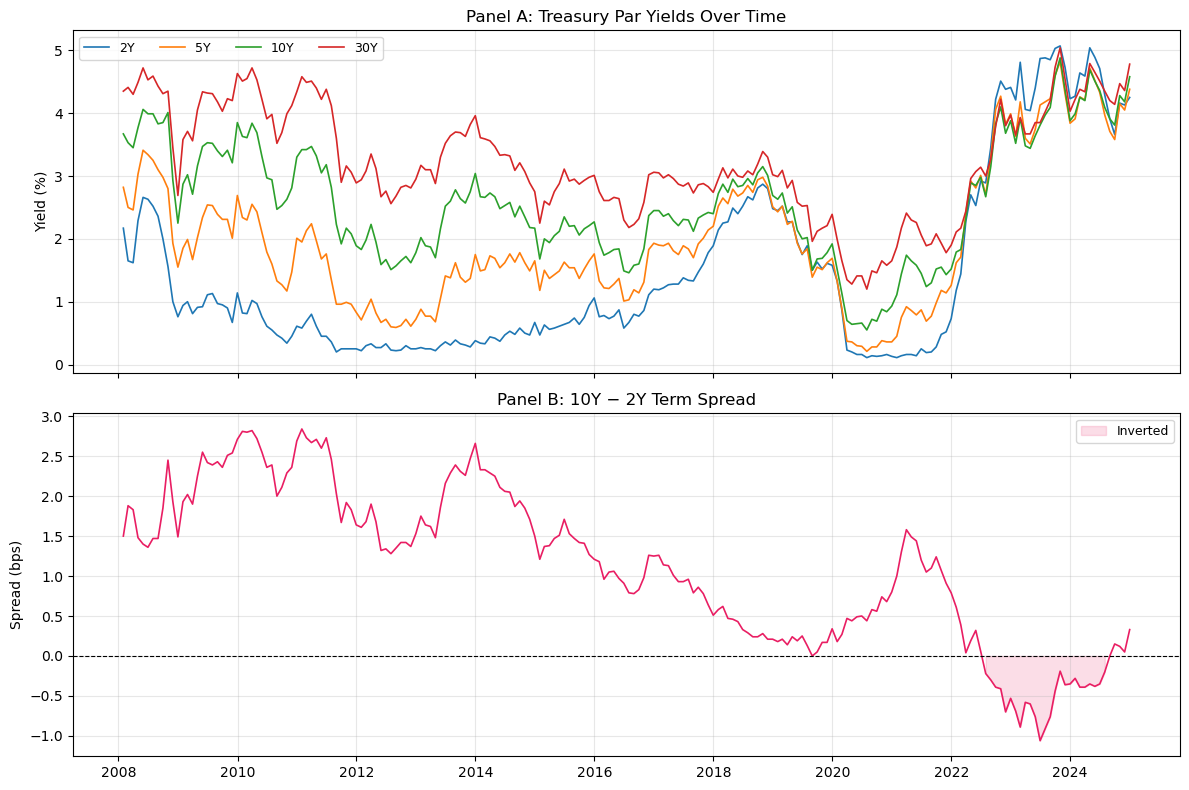

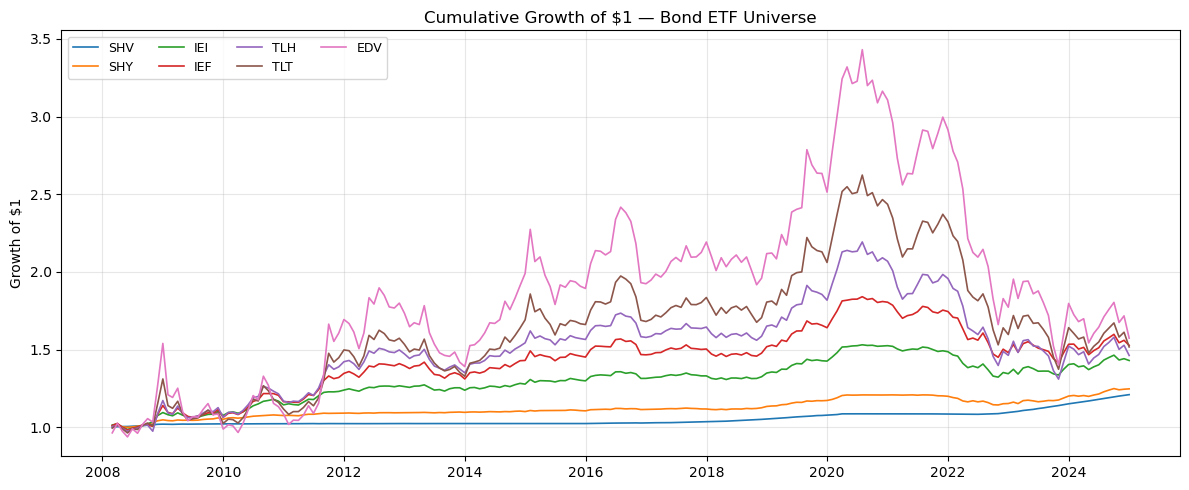

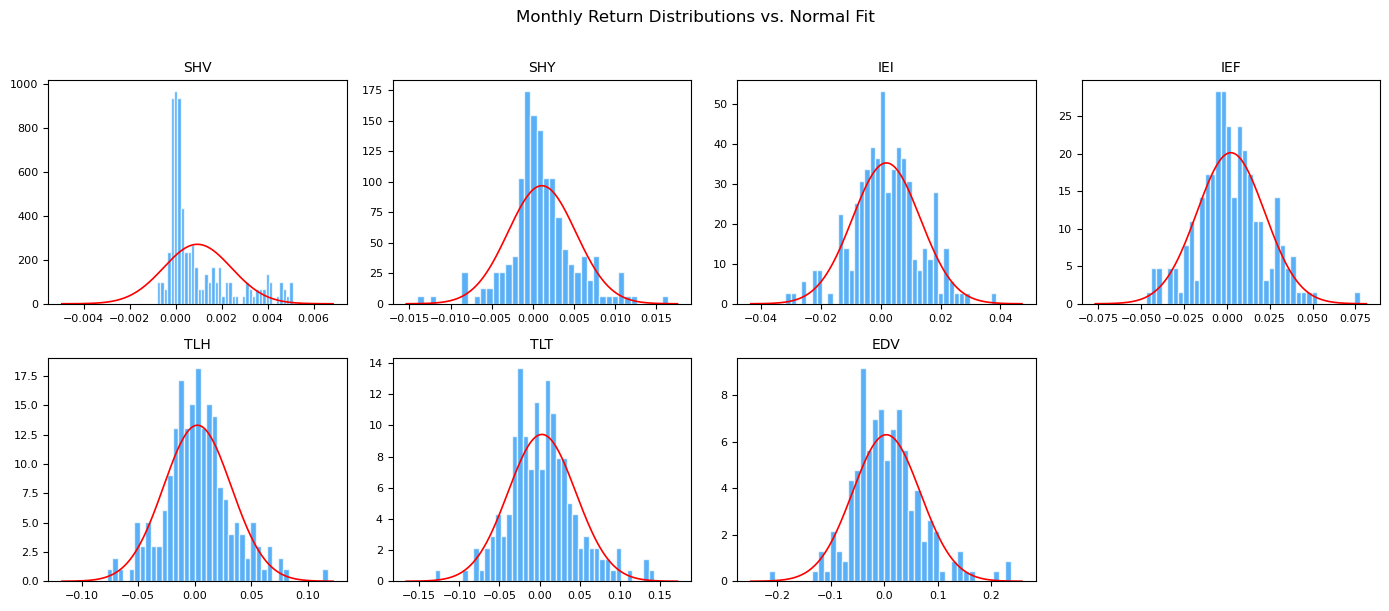

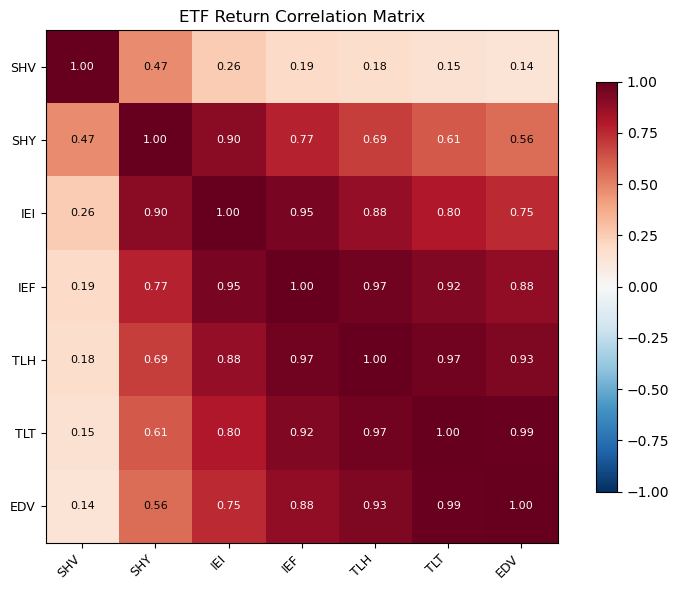

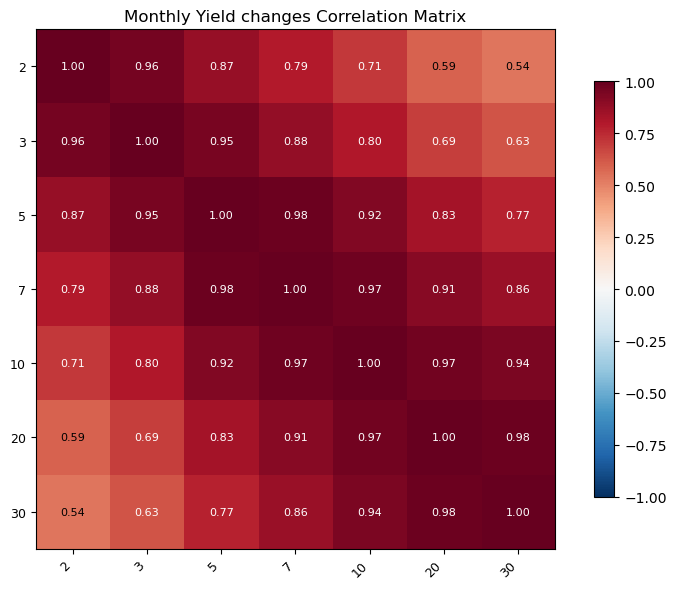

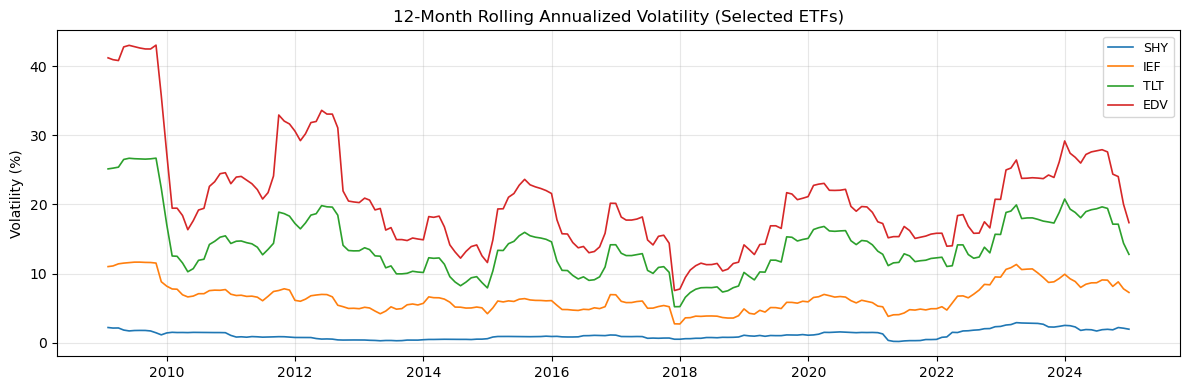

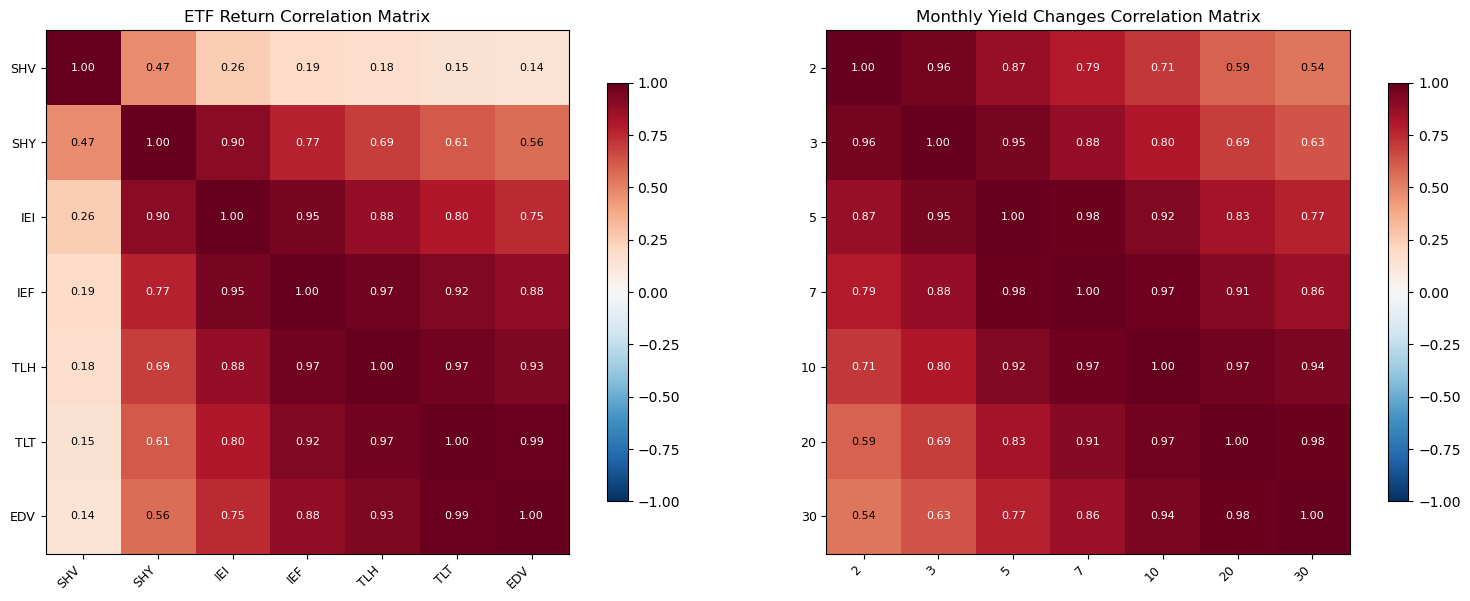

In [5]:
# Treasury Yield Summary Statistics

print("=== Treasury Yield Summary Statistics (annualized, in %) ===\n")
yield_stats = (yields * 100).describe().T
yield_stats['skew'] = (yields * 100).skew()
yield_stats['kurtosis'] = (yields * 100).kurtosis()
yield_stats.index.name = 'Maturity (yr)'
print(yield_stats.round(3))

# ETF Return Summary Statistics

returns_all = prices.pct_change().dropna()
ann_ret   = returns_all.mean() * 12
ann_vol   = returns_all.std() * np.sqrt(12)
ann_sr    = ann_ret / ann_vol
skew_ret  = returns_all.skew()
kurt_ret  = returns_all.kurtosis()
max_dd    = ((1 + returns_all).cumprod().div(
              (1 + returns_all).cumprod().cummax()) - 1).min()

etf_stats = pd.DataFrame({
    'Ann. Return (%)':  (ann_ret * 100).round(2),
    'Ann. Vol (%)':     (ann_vol * 100).round(2),
    'Sharpe':            ann_sr.round(3),
    'Skewness':          skew_ret.round(3),
    'Kurtosis':          kurt_ret.round(3),
    'Max Drawdown (%)': (max_dd * 100).round(2),
})
print("\n=== ETF Monthly Return Summary Statistics ===\n")
print(etf_stats)

# Yield Curve Time Series

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel A: selected yield maturities
for mat in [2, 5, 10, 30]:
    axes[0].plot(yields.index, yields[mat] * 100, label=f'{mat}Y', linewidth=1.2)
axes[0].set_ylabel('Yield (%)')
axes[0].set_title('Panel A: Treasury Par Yields Over Time')
axes[0].legend(ncol=4, fontsize=9)
axes[0].grid(alpha=0.3)

# Panel B: term spread (10Y − 2Y)
spread = (yields[10] - yields[2]) * 100
axes[1].plot(spread.index, spread, color='#E91E63', linewidth=1.2)
axes[1].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].fill_between(spread.index, spread, 0, where=spread < 0,
                     color='#E91E63', alpha=0.15, label='Inverted')
axes[1].set_ylabel('Spread (bps)')
axes[1].set_title('Panel B: 10Y − 2Y Term Spread')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('term_spread.png', dpi=300, bbox_inches='tight')
plt.show()

# ETF Cumulative Returns

fig, ax = plt.subplots(figsize=(12, 5))
cum = (1 + returns_all[ETFS]).cumprod()
for etf in ETFS:
    ax.plot(cum.index, cum[etf], label=etf, linewidth=1.2)
ax.set_title('Cumulative Growth of $1 — Bond ETF Universe')
ax.set_ylabel('Growth of $1')
ax.legend(ncol=4, fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ETF Return Distributions

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()
for i, etf in enumerate(ETFS):
    ax = axes[i]
    ax.hist(returns_all[etf].dropna(), bins=40, edgecolor='white',
            color='#2196F3', alpha=0.75, density=True)
    mu, sigma = returns_all[etf].mean(), returns_all[etf].std()
    x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.2)
    ax.set_title(etf, fontsize=10)
    ax.tick_params(labelsize=8)
for j in range(len(ETFS), len(axes)):
    axes[j].set_visible(False)
fig.suptitle('Monthly Return Distributions vs. Normal Fit', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('monthly_ret_dist.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation Matrix ETF Returns

corr = returns_all[ETFS].corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(ETFS)))
ax.set_yticks(range(len(ETFS)))
ax.set_xticklabels(ETFS, fontsize=9, rotation=45, ha='right')
ax.set_yticklabels(ETFS, fontsize=9)
for i in range(len(ETFS)):
    for j in range(len(ETFS)):
        ax.text(j, i, f'{corr.values[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr.values[i, j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('ETF Return Correlation Matrix')
plt.tight_layout()
plt.show()

# Correlation Matrix monthly yield changes

corr_y = np.log(yields.shift(1)/yields).dropna().corr()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_y.values, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(MATURITIES)))
ax.set_yticks(range(len(MATURITIES)))
ax.set_xticklabels(MATURITIES, fontsize=9, rotation=45, ha='right')
ax.set_yticklabels(MATURITIES, fontsize=9)
for i in range(len(MATURITIES)):
    for j in range(len(MATURITIES)):
        ax.text(j, i, f'{corr_y.values[i, j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if abs(corr_y.values[i, j]) > 0.6 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title('Monthly Yield changes Correlation Matrix')
plt.tight_layout()
plt.savefig('yield_changes.png', dpi=300, bbox_inches='tight')
plt.show()

# Rolling Volatility (12-month)

fig, ax = plt.subplots(figsize=(12, 4))
for etf in ['SHY', 'IEF', 'TLT', 'EDV']:
    roll_vol = returns_all[etf].rolling(12).std() * np.sqrt(12) * 100
    ax.plot(roll_vol.index, roll_vol, label=etf, linewidth=1.2)
ax.set_title('12-Month Rolling Annualized Volatility (Selected ETFs)')
ax.set_ylabel('Volatility (%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('volatility.png', dpi=300, bbox_inches='tight')
plt.show()

# Correlation Matrices side by side
corr = returns_all[ETFS].corr()
corr_y = np.log(yields.shift(1)/yields).dropna().corr()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, labels, title in zip(
    axes,
    [corr, corr_y],
    [ETFS, MATURITIES],
    ['ETF Return Correlation Matrix', 'Monthly Yield Changes Correlation Matrix']
):
    im = ax.imshow(matrix.values, cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, fontsize=9, rotation=45, ha='right')
    ax.set_yticklabels(labels, fontsize=9)
    for i in range(len(labels)):
        for j in range(len(labels)):
            ax.text(j, i, f'{matrix.values[i, j]:.2f}', ha='center', va='center', fontsize=8,
                    color='white' if abs(matrix.values[i, j]) > 0.6 else 'black')
    fig.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(title)

plt.tight_layout()
plt.savefig('correlation_matrices.png', dpi=300, bbox_inches='tight')
plt.show()



## 4. Nelson-Siegel Curve Fitting

Following Diebold & Li (2006), fit β₀, β₁, β₂ each month via cross-sectional OLS with fixed λ. Multicollinearity of the slope and curvature regressors is checked using the condition number diagnostic of Annaert et al. (2010). Residuals (observed minus fitted) are stored for use as the mispricing signal.

In [6]:
# Nelson-Siegel OLS estimation with fixed λ (Diebold & Li, 2006)
def ns_yield(tau, b0, b1, b2):
    lt = LAMBDA * tau
    l1 = (1 - np.exp(-lt)) / lt
    l2 = l1 - np.exp(-lt)
    return b0 + b1 * l1 + b2 * l2

def ns_loadings(tau, lam):
    """Construct the NS regressor matrix for given maturities and fixed λ."""
    lt = lam * tau
    l1 = (1 - np.exp(-lt)) / lt
    l2 = l1 - np.exp(-lt)
    return np.column_stack([np.ones_like(tau), l1, l2])

mats = np.array(MATURITIES, dtype=float)
X = ns_loadings(mats, LAMBDA)

# Condition number diagnostic (Annaert et al., 2010)
# Check slope & curvature regressors only (columns 1 and 2)
kappa = np.linalg.cond(X[:, 1:])
print(f'Condition number of slope/curvature regressors: {kappa:.2f}')
print(f'Multicollinearity concern: {"Yes (consider ridge)" if kappa >= 10 else "No — OLS appropriate"} (threshold = 10)\n')

# Cross-sectional OLS each month: y = X @ beta
betas, residuals = [], []
for date, row in yields.iterrows():
    y_obs = row.values
    b, _, _, _ = np.linalg.lstsq(X, y_obs, rcond=None)
    fitted = X @ b
    betas.append({'date': date, 'b0': b[0], 'b1': b[1], 'b2': b[2]})
    residuals.append(dict(zip(mats, y_obs - fitted)))

factors_df   = pd.DataFrame(betas).set_index('date')
residuals_df = pd.DataFrame(residuals, index=yields.index)

print(f'Factors shape: {factors_df.shape}')
factors_df.tail(3)

Condition number of slope/curvature regressors: 6.64
Multicollinearity concern: No — OLS appropriate (threshold = 10)

Factors shape: (204, 3)


,b0,b1,b2
date,,,
2024-10-31,0.043624,-0.003523,0.010814
2024-11-30,0.047673,-0.007468,-0.000244
2024-12-31,0.037607,0.002973,0.030559


## 5. Diebold-Li VAR(1) Forecasts

Following Diebold & Li (2006), treat the three NS factors as a system and model their joint dynamics with a VAR(1). Expanding window — the model is refit on all data up to 't', then used to forecast factors at 't+1'. First 'VAR_INIT_MONTHS' months initialize the window.

In [7]:
forecasts = pd.DataFrame(index=factors_df.index, columns=['b0', 'b1', 'b2'], dtype=float)

for i in range(36, len(factors_df)):
    train = factors_df.iloc[:i]
    try:
        fcast = VAR(train).fit(1).forecast(train.values[-1:], steps=1)[0]
        forecasts.iloc[i] = fcast
    except Exception:
        pass  # skip months where VAR fails to converge (rare)

print(f'Forecast coverage: {forecasts.dropna().shape[0]} months')
forecasts.dropna().tail(3)

Forecast coverage: 168 months


,b0,b1,b2
date,,,
2024-10-31,0.046548,-0.012162,0.003399
2024-11-30,0.044048,-0.004181,0.010055
2024-12-31,0.047919,-0.007913,-0.000620


## 6. Helper Functions

Define 'factor_loading', 'zscore', weighting schemes, 'run_backtest', and 'metrics' before they are called in the analysis sections below.

In [8]:
# Factor loading (NS basis function value at a given maturity)
def factor_loading(factor, mat):
    lt = LAMBDA * mat
    l1 = (1 - np.exp(-lt)) / lt
    l2 = l1 - np.exp(-lt)
    if factor == 'b0': return 1.0
    if factor == 'b1': return l1
    if factor == 'b2': return l2

# Cross-sectional z-score
def zscore(df):
    return df.sub(df.mean(axis=1), axis=0).div(df.std(axis=1).replace(0, np.nan), axis=0)

# Weighting schemes
fallback = pd.Series(1 / len(ETFS), index=ETFS)

def signal_prop_weights(x):
    shifted = x - x.min()
    if shifted.sum() == 0:
        return pd.Series(1 / len(ETFS), index=x.index)
    return shifted / shifted.sum()

def top_n_weights(x, n=TOP_N):
    w = pd.Series(0.0, index=x.index)
    w[x.nlargest(n).index] = 1.0 / n
    return w

# Backtest engine
returns = prices.pct_change().dropna()

def run_backtest(weights):
    w_shifted = weights.shift(1).dropna()
    idx = w_shifted.index.intersection(returns.index)
    return (w_shifted.loc[idx] * returns.loc[idx, ETFS]).sum(axis=1)

# Performance metrics + Jobson-Korkie test
def metrics(r, label):
    cagr    = (1 + r).prod() ** (12 / len(r)) - 1
    vol     = r.std() * np.sqrt(12)
    sharpe  = (r.mean()*12) / (r.std() * np.sqrt(12))
    down    = r[r < 0].std() * np.sqrt(12)
    sortino = cagr / down if down > 0 else np.nan
    cum     = (1 + r).cumprod()
    max_dd  = ((cum - cum.cummax()) / cum.cummax()).min()
    print(f'{label:<30} CAGR: {cagr*100:5.2f}%  Vol: {vol*100:5.2f}%  '
          f'Sharpe: {sharpe:.3f}  Sortino: {sortino:.3f}  MaxDD: {max_dd*100:.2f}%')

def jk_test(r_s, r_b):
    n    = len(r_s)
    sr_s = r_s.mean() / r_s.std()
    sr_b = r_b.mean() / r_b.std()
    corr = np.corrcoef(r_s, r_b)[0, 1]
    se   = np.sqrt((1/n) * (2 - 2*corr + 0.5*(sr_s**2 + sr_b**2 - 2*sr_s*sr_b*corr**2)))
    z    = (sr_s - sr_b) / se
    p    = 2 * (1 - stats.norm.cdf(abs(z)))
    return z, p

## 7. Signal Decomposition: Nelson-Siegel vs. Diebold-Li

Run each signal in isolation before combining them. The NS-only strategy uses purely the mispricing residuals; the DL-only strategy uses purely the VAR(1) directional forecast. This establishes which component adds more value.

In [9]:
# NS-only: mispricing residuals, no forecast
mis = pd.DataFrame({
    etf: residuals_df.apply(
        lambda r: float(np.interp(mat, residuals_df.columns.astype(float), r.values)), axis=1)
    for etf, mat in ETF_MATS.items()
})
weights_ns_only = zscore(mis).apply(
    lambda r: signal_prop_weights(r) if not r.isna().any() else fallback, axis=1)
strat_ns_only = run_backtest(weights_ns_only)

# DL-only: VAR(1) directional forecast, no mispricing
current_yield = pd.DataFrame({
    etf: factors_df.apply(
        lambda r: ns_yield(np.array([mat]), r['b0'], r['b1'], r['b2'])[0], axis=1)
    for etf, mat in ETF_MATS.items()
})
forecast_yield = pd.DataFrame({
    etf: forecasts.apply(
        lambda r: ns_yield(np.array([mat]), r['b0'], r['b1'], r['b2'])[0]
        if not r.isna().any() else np.nan, axis=1)
    for etf, mat in ETF_MATS.items()
})
dir_ = -(forecast_yield - current_yield)
weights_dl_only = zscore(dir_).apply(
    lambda r: signal_prop_weights(r) if not r.isna().any() else fallback, axis=1)
strat_dl_only = run_backtest(weights_dl_only)

# Benchmark
bench_ret = returns[ETFS].mean(axis=1).loc[strat_ns_only.index]

print('Signal Decomposition — Full Period')
for r, label in [
    (strat_ns_only, 'Nelson-Siegel only'),
    (strat_dl_only, 'Diebold-Li only'),
    (bench_ret,     'Equal Weight'),
]:
    metrics(r, label)

Signal Decomposition — Full Period
Nelson-Siegel only             CAGR:  1.32%  Vol:  7.83%  Sharpe: 0.207  Sortino: 0.249  MaxDD: -34.62%
Diebold-Li only                CAGR:  2.82%  Vol:  8.09%  Sharpe: 0.384  Sortino: 0.539  MaxDD: -20.84%
Equal Weight                   CAGR:  2.37%  Vol:  8.17%  Sharpe: 0.327  Sortino: 0.527  MaxDD: -28.76%


## 8. Individual Factor Attribution

Run each Diebold-Li factor (β₀ level, β₁ slope, β₂ curvature) in isolation. The slope factor β₁ consistently dominates, motivating the 60/20/20 tilt applied in Section 9.

Individual Factor Signals — Full Period
β₀ Level                       CAGR:  2.37%  Vol:  8.17%  Sharpe: 0.327  Sortino: 0.527  MaxDD: -28.76%
β₁ Slope                       CAGR:  3.84%  Vol:  9.55%  Sharpe: 0.441  Sortino: 0.719  MaxDD: -19.77%
β₂ Curvature                   CAGR:  2.44%  Vol:  8.17%  Sharpe: 0.336  Sortino: 0.422  MaxDD: -27.02%
Equal Weight                   CAGR:  2.37%  Vol:  8.17%  Sharpe: 0.327  Sortino: 0.527  MaxDD: -28.76%


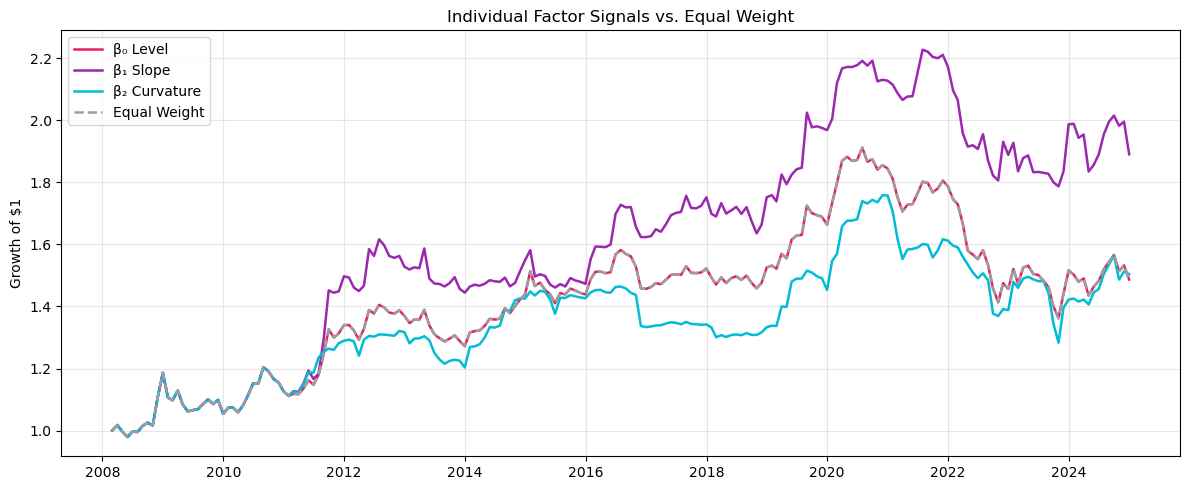

In [11]:
factor_signals = {}
for factor in ['b0', 'b1', 'b2']:
    delta = forecasts[factor] - factors_df[factor]
    sig = pd.DataFrame({
        etf: -delta * factor_loading(factor, mat)
        for etf, mat in ETF_MATS.items()
    })
    factor_signals[factor] = sig

weights_b0 = factor_signals['b0'].apply(lambda r: signal_prop_weights(r) if not r.isna().any() else fallback, axis=1)
weights_b1 = factor_signals['b1'].apply(lambda r: signal_prop_weights(r) if not r.isna().any() else fallback, axis=1)
weights_b2 = factor_signals['b2'].apply(lambda r: signal_prop_weights(r) if not r.isna().any() else fallback, axis=1)

strat_b0 = run_backtest(weights_b0)
strat_b1 = run_backtest(weights_b1)
strat_b2 = run_backtest(weights_b2)

print('Individual Factor Signals — Full Period')
for r, label in [
    (strat_b0, 'β₀ Level'),
    (strat_b1, 'β₁ Slope'),
    (strat_b2, 'β₂ Curvature'),
    (bench_ret, 'Equal Weight'),
]:
    metrics(r, label)

fig, ax = plt.subplots(figsize=(12, 5))
for r, label, color in [
    (strat_b0, 'β₀ Level', '#E91E63'),
    (strat_b1, 'β₁ Slope', '#9C27B0'),
    (strat_b2, 'β₂ Curvature', '#00BCD4'),
    (bench_ret, 'Equal Weight', '#9E9E9E'),
]:
    cum = (1 + r).cumprod()
    ls  = '--' if label == 'Equal Weight' else '-'
    ax.plot(cum.index, cum, label=label, linewidth=1.8, linestyle=ls, color=color)

ax.set_title('Individual Factor Signals vs. Equal Weight')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('ind_factor.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Signal Construction & Portfolio Weights

With the decomposition and factor attribution above establishing that the directional signal outperforms mispricing alone and β₁ carries the most predictive power, the final signal applies a 60/20/20 factor tilt and combines both signals with equal weight.

In [12]:
# Directional signal: β₁-tilted VAR forecast
dir_tilted = pd.DataFrame(index=factors_df.index, columns=ETFS, dtype=float)
for etf, mat in ETF_MATS.items():
    weighted_delta = sum(
        FACTOR_WEIGHTS[f] * (forecasts[f] - factors_df[f]) * factor_loading(f, mat)
        for f in ['b0', 'b1', 'b2']
    )
    dir_tilted[etf] = -weighted_delta

# Combined signal
combined = 0.5 * zscore(mis) + 0.5 * zscore(dir_tilted)

# Portfolio weights
N_ETFS = len(ETFS)
fallback = pd.Series(1 / N_ETFS, index=ETFS)

weights_final = combined.apply(lambda r: signal_prop_weights(r) if not r.isna().any() else fallback, axis=1)
weights_top_n = combined.apply(lambda r: top_n_weights(r)       if not r.isna().any() else fallback, axis=1)

print(f'Average weights — Signal Proportional:')
print(weights_final.mean().round(3))
print(f'\nAverage weights — Top-{TOP_N}:')
print(weights_top_n.mean().round(3))

Average weights — Signal Proportional:
SHV    0.151
SHY    0.149
IEI    0.127
IEF    0.168
TLH    0.131
TLT    0.119
EDV    0.154
dtype: float64

Average weights — Top-3:
SHV    0.162
SHY    0.102
IEI    0.130
IEF    0.194
TLH    0.123
TLT    0.123
EDV    0.166
dtype: float64


## 10. Backtest

Weights are lagged one period to avoid look-ahead bias — signal at 't' goes into the portfolio held during 't+1'.

In [13]:
strat_final = run_backtest(weights_final)
strat_topn  = run_backtest(weights_top_n)

idx = strat_final.index
bench_ret = returns.loc[idx, ETFS].mean(axis=1)

print(f'Backtest period: {idx[0].date()} to {idx[-1].date()}  ({len(idx)} months)')

Backtest period: 2008-02-29 to 2024-12-31  (203 months)


## 11. Performance Metrics

Jobson-Korkie (1981) test for statistical significance of Sharpe ratio differences. Tracking error is annualized.

In [14]:
print('Full Period Performance')
for r, label in [
    (strat_final, f'Signal Proportional'),
    (strat_topn,  f'Top-{TOP_N}'),
    (bench_ret,   'Equal Weight'),
]:
    metrics(r, label)

print('\nJobson-Korkie vs Equal Weight')
for r, label in [(strat_final, 'Signal Proportional'), (strat_topn, f'Top-{TOP_N}')]:
    z, p = jk_test(r, bench_ret)
    te   = (r - bench_ret).std() * np.sqrt(12) * 100
    print(f'{label:<30} JK z: {z:6.3f}  p: {p:.3f}  TE: {te:.2f}%')

Full Period Performance
Signal Proportional            CAGR:  2.79%  Vol:  8.52%  Sharpe: 0.366  Sortino: 0.559  MaxDD: -25.75%
Top-3                          CAGR:  3.84%  Vol:  9.79%  Sharpe: 0.433  Sortino: 0.690  MaxDD: -26.55%
Equal Weight                   CAGR:  2.37%  Vol:  8.17%  Sharpe: 0.327  Sortino: 0.527  MaxDD: -28.76%

Jobson-Korkie vs Equal Weight
Signal Proportional            JK z:  0.509  p: 0.611  TE: 2.59%
Top-3                          JK z:  0.982  p: 0.326  TE: 4.24%


## 12. Results — Full Period (2009–2024)

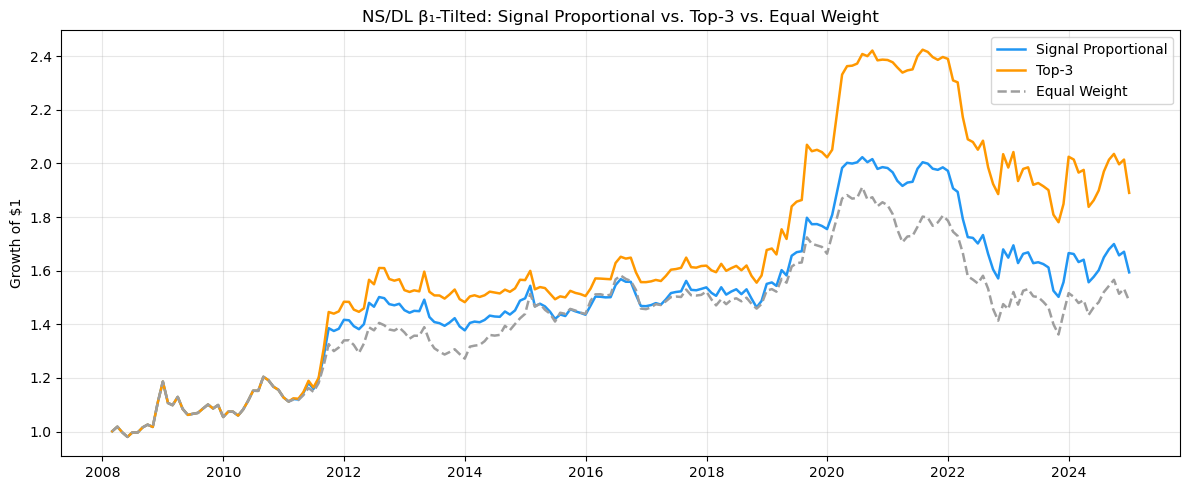

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
for r, label, color in [
    (strat_final, 'Signal Proportional', '#2196F3'),
    (strat_topn, f'Top-{TOP_N}', '#FF9800'),
    (bench_ret, 'Equal Weight', '#9E9E9E'),
]:
    cum = (1 + r).cumprod()
    ls  = '--' if label == 'Equal Weight' else '-'
    ax.plot(cum.index, cum, label=label, linewidth=1.8, linestyle=ls, color=color)

ax.set_title(f'NS/DL β₁-Tilted: Signal Proportional vs. Top-{TOP_N} vs. Equal Weight')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('full_period.png', dpi=300, bbox_inches='tight')
plt.show()

## 13. Sub-Period (2018–2021)

The 2018–2021 window captures two distinct regimes: the 2019 Fed rate-cut cycle and the 2020 COVID shock. Both periods had directional moves in the yield curve the environment where a slope-forecasting model adds the most value.

In [17]:
def sub(r):
    return r[(r.index >= SUB_START) & (r.index <= SUB_END)]
QPM/Project/Nelson-Siegel_Diebold-Li_VAR_Bond_ETF_Strategy_organized.ipynb
print(f'── {SUB_START[:4]}–{SUB_END[:4]}')
for r, label in [
    (strat_final, 'Signal Proportional'),
    (strat_topn,  f'Top-{TOP_N}'),
    (bench_ret,   'Equal Weight'),
]:
    metrics(sub(r), label)

fig, ax = plt.subplots(figsize=(12, 5))
for r, label, color in [
    (strat_final, 'Signal Proportional', '#2196F3'),
    (strat_topn,  f'Top-{TOP_N}',        '#FF9800'),
    (bench_ret,   'Equal Weight',        '#9E9E9E'),
]:
    s   = sub(r)
    cum = (1 + s).cumprod()
    cum = cum / cum.iloc[0]
    ls  = '--' if label == 'Equal Weight' else '-'
    ax.plot(cum.index, cum, label=label, linewidth=1.8, linestyle=ls, color=color)

ax.set_title(f'NS/DL β₁-Tilted — {SUB_START[:4]}–{SUB_END[:4]}')
ax.set_ylabel('Growth of $1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('full_subper.png', dpi=300, bbox_inches='tight')
plt.show()

NameError: name 'QPM' is not defined

Nelson, C.R. and Siegel, A.F. (1987). "Parsimonious Modeling of Yield Curves." Journal of Business, 60(4), 473–489.

Diebold, F.X. and Li, C. (2006). "Forecasting the Term Structure of Government Bond Yields." Journal of Econometrics, 130(2), 337–364.